In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


In [2]:

import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:

GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]



In [4]:

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells'
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells'
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)


mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell'
cell_NDNF_model_ranks20_contig_x00_cue = get_model_data_per_cell(mse_dir)

    
fixed_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_cue[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_contig_x00_cue[20][animal-18] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict


cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [5]:

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell'
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue = {20: {}}
for idx, animal in enumerate(real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue[20][animal-18] = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20][animal]
        

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [6]:

import pickle

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_early.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_early = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_late.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_late = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_overall.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_overall = pickle.load(f)
    
file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_early.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_early = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_late.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_late = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_overall.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_overall = pickle.load(f)
    
file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_early.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_SST_early = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_late.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_SST_late = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_overall.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_SST_overall = pickle.load(f)
    
file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_middle.pkl" 
with open(file_path, 'rb') as f:
    clusters_dict_SST_middle = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_middle.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_middle = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_middle.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_middle = pickle.load(f)



/Users/michaelfinch/CA1-interneuron-GLM/SliceTCA_example.py:480: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}


total_num_trials 66


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


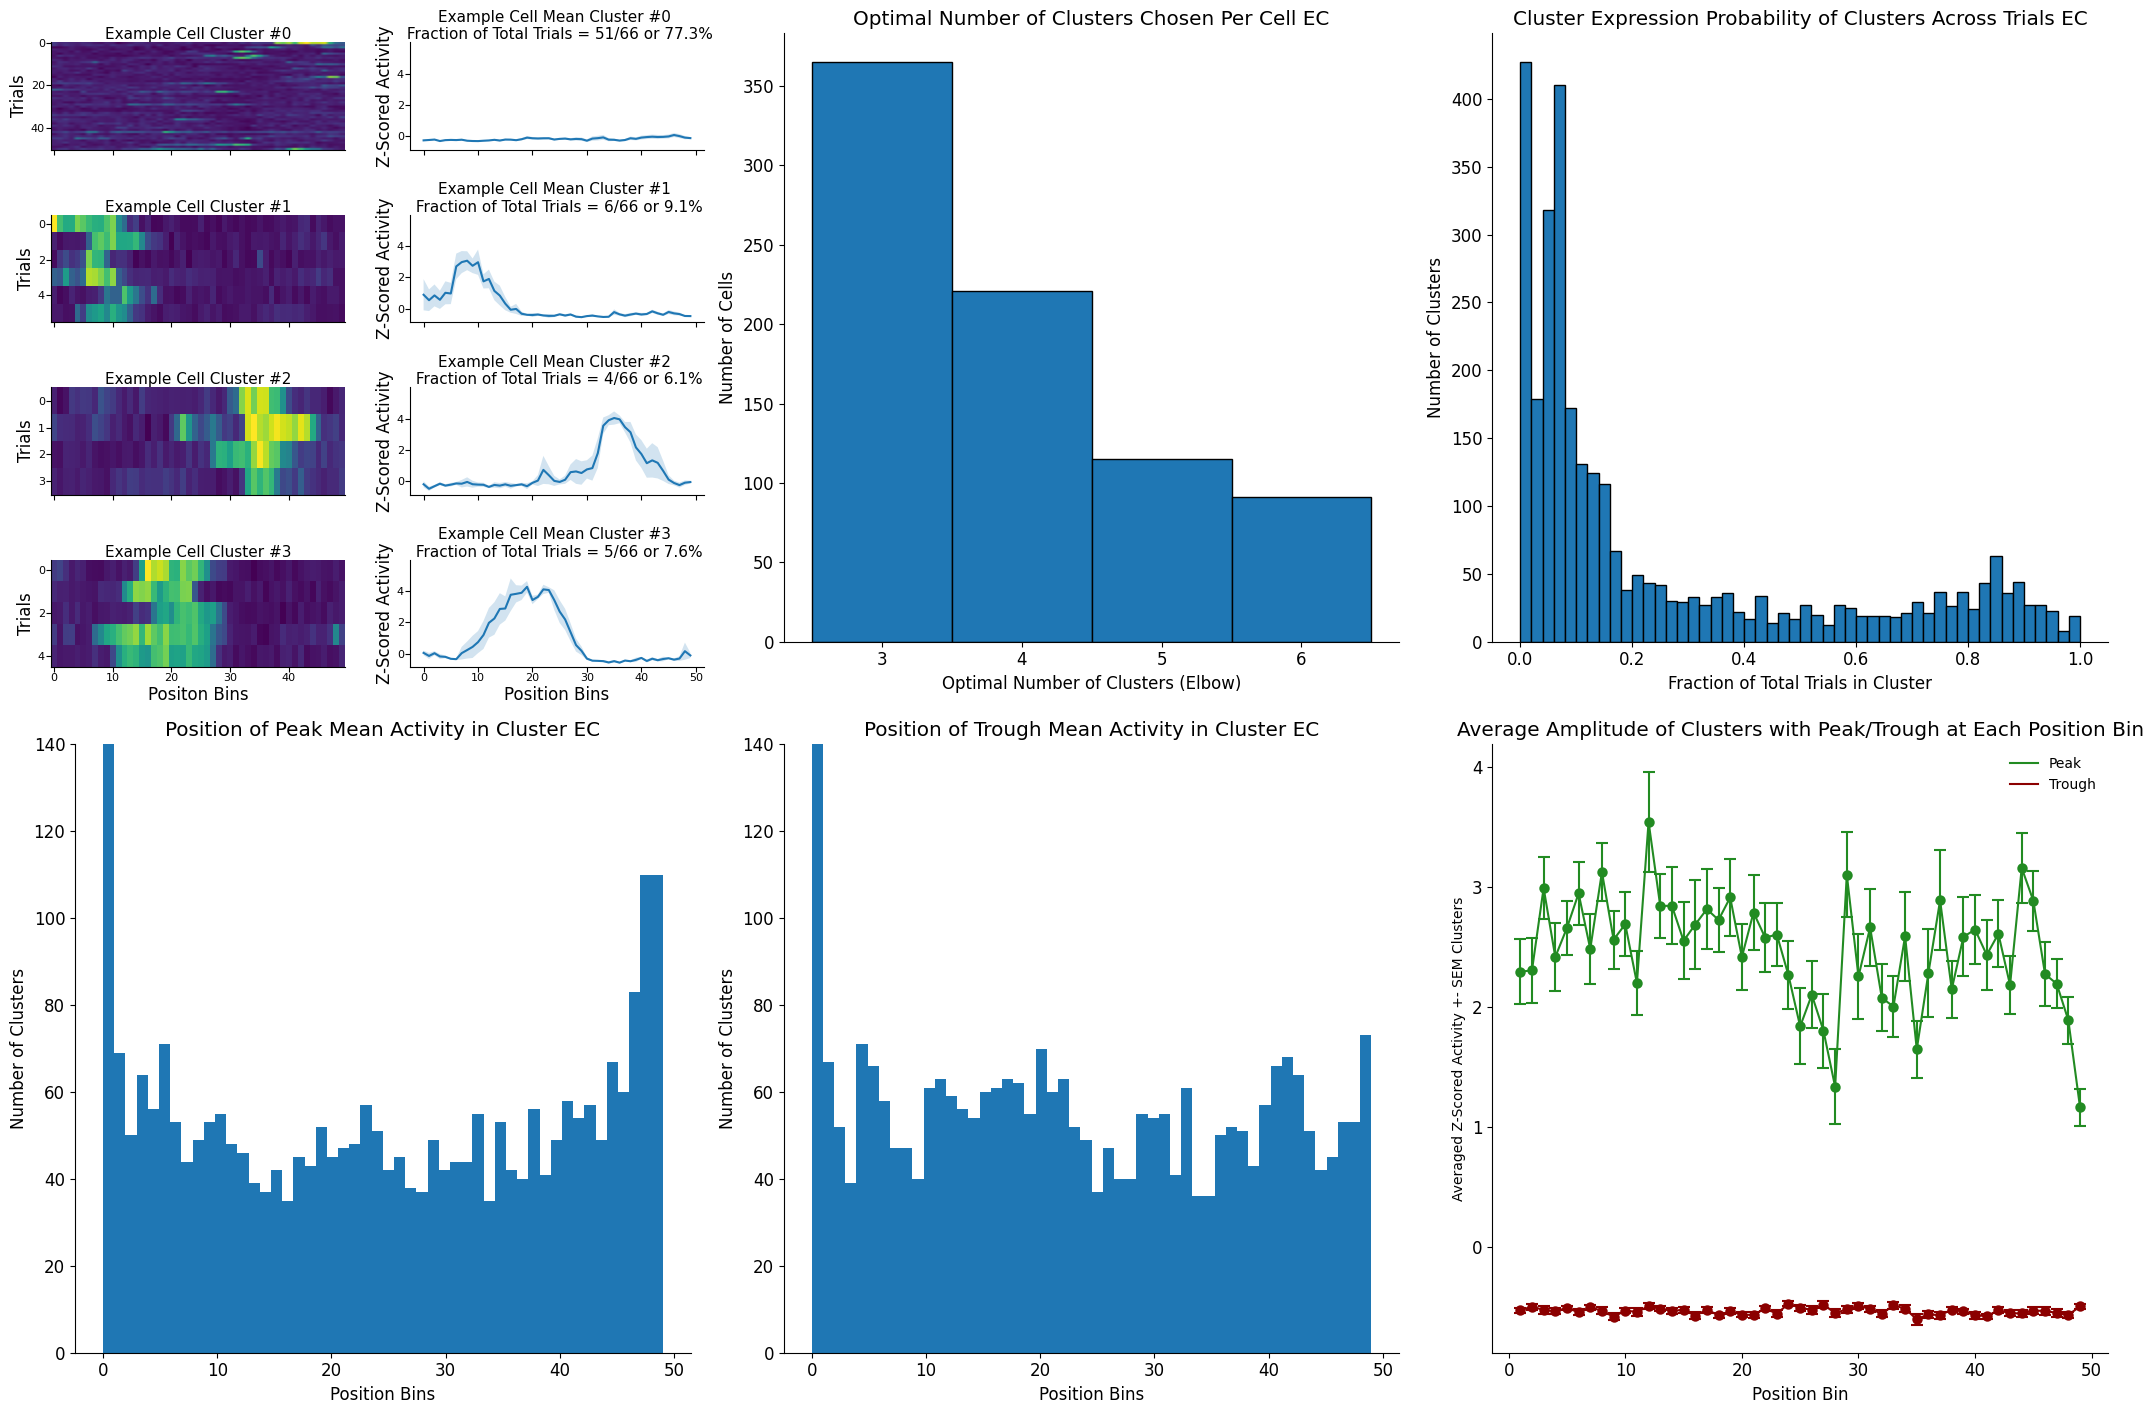

In [7]:
all_means_list_peak_EC, all_means_list_trough_EC, proportion_trials_per_cluster_EC = plot_pop_stats(clusters_dict_EC_overall, cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, cell_type="EC", animal='animal_2', cell='cell_4', ylim=140)

In [8]:
indices_dict_EC_overall = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, split_learn=False, eln="nothing")
activity_indices_EC_dict_overall = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_overall)

indices_dict_EC_overall['animal_1']['cell_2']

/Users/michaelfinch/CA1-interneuron-GLM/SliceTCA_example.py:480: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}


{0: array([12, 14, 36, 38, 53, 56, 64, 69, 72, 77]),
 1: array([ 0,  8, 49]),
 2: array([ 1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 13, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 39,
        40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 54, 55, 57, 58, 59,
        60, 61, 62, 63, 65, 66, 67, 68, 70, 71, 73, 74, 75, 76])}

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


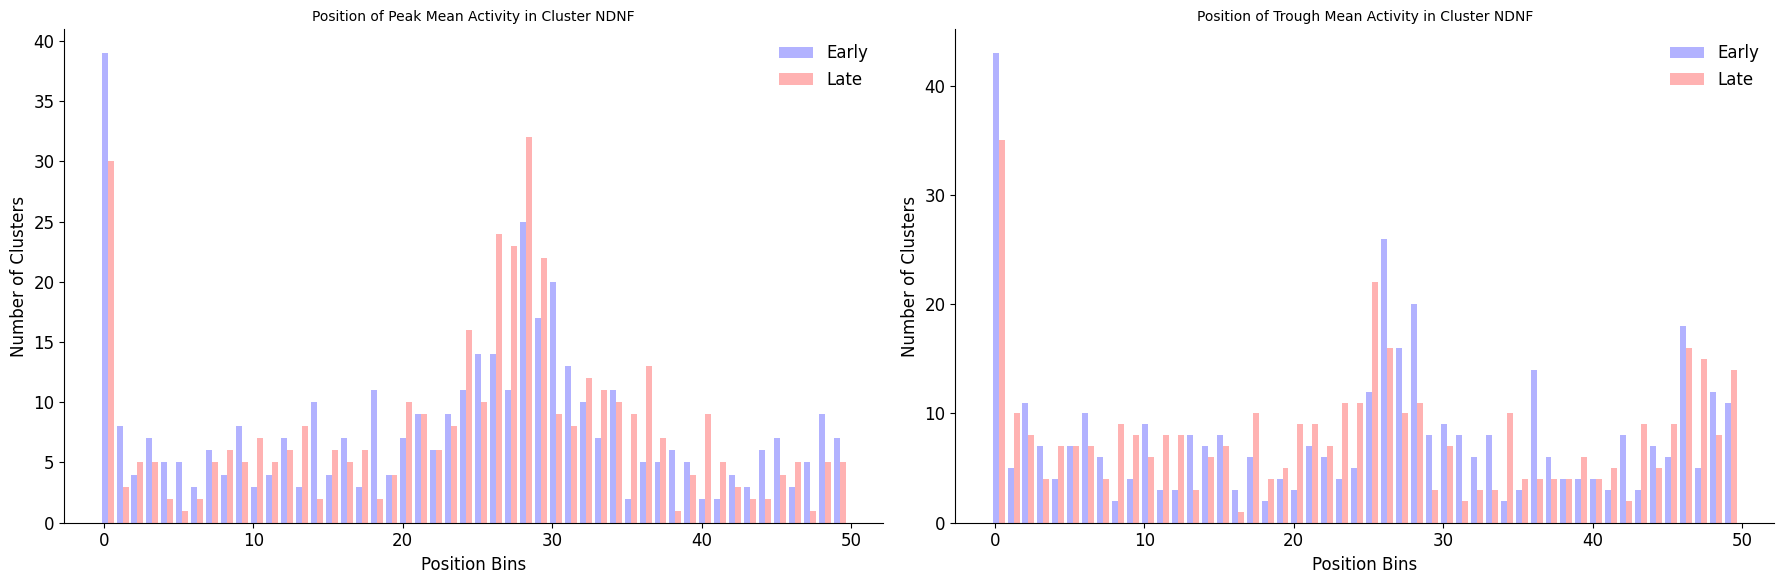

In [58]:
def plot_peak_trough_bargraphs(clusters_dict_NDNF_early, clusters_dict_NDNF_late, use_argmax=True, title=None, ylim=None, ax=None, alpha=0.7):
    import numpy as np

    early_means = []
    late_means = []

    # Collect early data
    for animal in clusters_dict_NDNF_early:
        for cell in clusters_dict_NDNF_early[animal]:
            for i in range(len(clusters_dict_NDNF_early[animal][cell])):
                data = clusters_dict_NDNF_early[animal][cell][i]
                mean_data = np.mean(data, axis=0)
                early_means.append(np.argmax(mean_data) if use_argmax else np.argmin(mean_data))

    # Collect late data
    for animal in clusters_dict_NDNF_late:
        for cell in clusters_dict_NDNF_late[animal]:
            for i in range(len(clusters_dict_NDNF_late[animal][cell])):
                data = clusters_dict_NDNF_late[animal][cell][i]
                mean_data = np.mean(data, axis=0)
                late_means.append(np.argmax(mean_data) if use_argmax else np.argmin(mean_data))

    # Bin counts
    bins = np.arange(0, 51)  # Assuming 50 bins
    early_counts, _ = np.histogram(early_means, bins=bins)
    late_counts, _ = np.histogram(late_means, bins=bins)

    bin_centers = bins[:-1] + 0.25  # Center of each bin
    width = 0.4  # Width of each bar

    # Plot paired bars
    ax.bar(bin_centers - width/2, early_counts, width=width, color='blue', alpha=alpha, label='Early')
    ax.bar(bin_centers + width/2, late_counts, width=width, color='red', alpha=alpha, label='Late')

    ax.set_title(f"Position of {'Peak' if use_argmax else 'Trough'} Mean Activity in Cluster {title}", fontsize=10)
    ax.set_ylabel("Number of Clusters")
    ax.set_xlabel("Position Bins")
    ax.set_ylim(0, ylim)
    ax.legend()

    return early_means, late_means

fig, axs = plt.subplots(1,2, figsize=(18,6))
early_means, late_means = plot_peak_trough_bargraphs(clusters_dict_NDNF_early, clusters_dict_NDNF_late, use_argmax=True, title="NDNF", ylim=None, ax=axs[0], alpha=0.3)
early_means, late_means = plot_peak_trough_bargraphs(clusters_dict_NDNF_early, clusters_dict_NDNF_late, use_argmax=False, title="NDNF", ylim=None, ax=axs[1], alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
indices_dict_EC_early = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, split_learn=True, eln="early")
activity_indices_EC_dict_early = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_early)
indices_dict_EC_early['animal_1']['cell_1']


early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
earl

/Users/michaelfinch/CA1-interneuron-GLM/SliceTCA_example.py:480: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}


{0: [9, 11, 13, 21],
 1: [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  10,
  12,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  22,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  34,
  35,
  36,
  37,
  38,
  39],
 2: [8, 23],
 3: [33]}

In [16]:
indices_dict_EC_early = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, split_learn=True, eln="early")
activity_indices_EC_dict_early = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_early)
indices_dict_EC_early['animal_1']['cell_1']


indices_dict_EC_late = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, split_learn=True, eln="late")
activity_indices_EC_dict_late = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_late)
indices_dict_EC_late['animal_1']['cell_1']

{0: [57, 61, 68, 69, 74],
 1: [58, 59, 62, 63, 64, 65, 66, 71, 72, 73, 75, 76, 77],
 2: [56, 60, 67],
 3: [70]}

In [30]:
indices_dict_SST_early = get_indices_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, split_learn=True, eln="early")
activity_indices_SST_dict_early = get_activity_from_indices(residual_activity_dict_SST, indices_dict_SST_early)


indices_dict_SST_late = get_indices_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, split_learn=True, eln="late")
activity_indices_SST_dict_late = get_activity_from_indices(residual_activity_dict_SST, indices_dict_SST_late)


early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
early
earl

/Users/michaelfinch/CA1-interneuron-GLM/SliceTCA_example.py:531: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  "sem": sem(peak_per_cluster_list)}
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


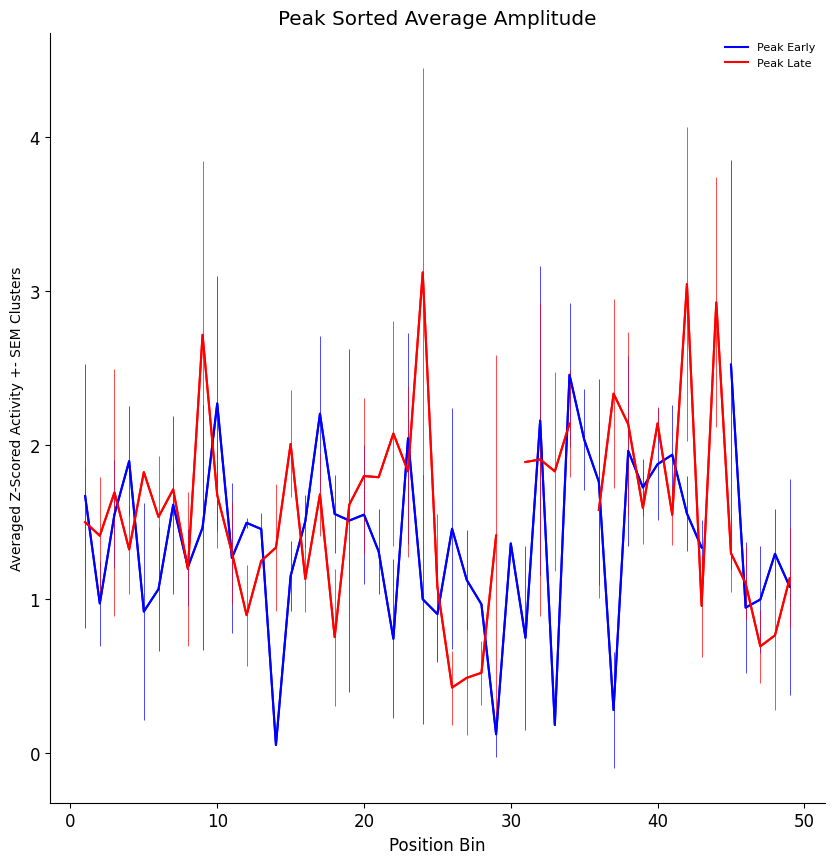

In [117]:
def plot_means_sems_max_min_learning(activity_indices_EC_dict_early, activity_indices_EC_dict_late, ax=None, plot_peak=True, alpha=None):
    mean_data_by_peak_early, max_bin = get_data_by_peak(activity_indices_EC_dict_early, use_peak=True)
    mean_data_by_peak_late, max_bin = get_data_by_peak(activity_indices_EC_dict_late, use_peak=True)

    mean_data_by_trough_early, min_bin = get_data_by_peak(activity_indices_EC_dict_early, use_peak=False)
    mean_data_by_trough_late, min_bin = get_data_by_peak(activity_indices_EC_dict_late, use_peak=False)

    means_peak_early, sems_peak_early = mean_sems_peak_trough(mean_data_by_peak_early, max_bin, use_peak=True)
    means_peak_late, sems_peak_late = mean_sems_peak_trough(mean_data_by_peak_late, max_bin, use_peak=True)

    means_trough_early, sems_trough_early = mean_sems_peak_trough(mean_data_by_trough_early, min_bin, use_peak=False)
    means_trough_late, sems_trough_late = mean_sems_peak_trough(mean_data_by_trough_late, min_bin, use_peak=False)

    x = np.arange(max_bin)

    if plot_peak:
        ax.plot(means_peak_early, color="blue", label="Peak Early", alpha=alpha)
        ax.errorbar(x, means_peak_early, yerr=sems_peak_early, elinewidth=0.5, color='blue', alpha=alpha)
        ax.plot(means_peak_late, color="red", label="Peak Late", alpha=alpha)
        ax.errorbar(x, means_peak_late, yerr=sems_peak_late, elinewidth=0.5, color='red', alpha=alpha)
        
        ax.set_title('Peak Sorted Average Amplitude')

    else:
        ax.plot(means_trough_early, color="purple", label="Trough Early", alpha=alpha)
        ax.errorbar(x, means_trough_early, yerr=sems_trough_early, elinewidth=0.5, color='purple', alpha=alpha)
        ax.plot(means_trough_late, color="magenta", label="Trough Late", alpha=alpha)
        ax.errorbar(x, means_trough_late, yerr=sems_trough_late, elinewidth=0.5, color='magenta', alpha=alpha)
        ax.set_title('Trough Sorted Average Amplitude')


    ax.set_xlabel('Position Bin')
    ax.set_ylabel('Averaged Z-Scored Activity +- SEM Clusters', fontsize=10)
    ax.legend(fontsize=8)
    
fig, axs = plt.subplots(figsize=(10,10))
plot_means_sems_max_min_learning(activity_indices_SST_dict_early, activity_indices_SST_dict_late, ax=axs)
plt.show()

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_56580/4141913681.py:17: RuntimeWarning: Mean of empty slice
  m = np.nanmean(A, axis=0)              # mean ignoring NaN
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


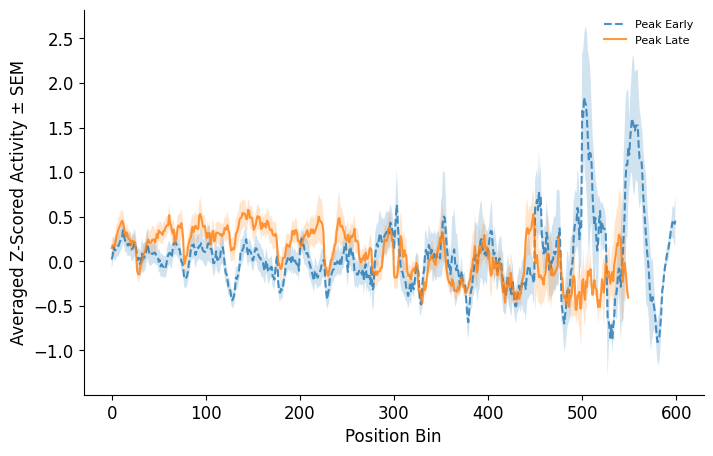

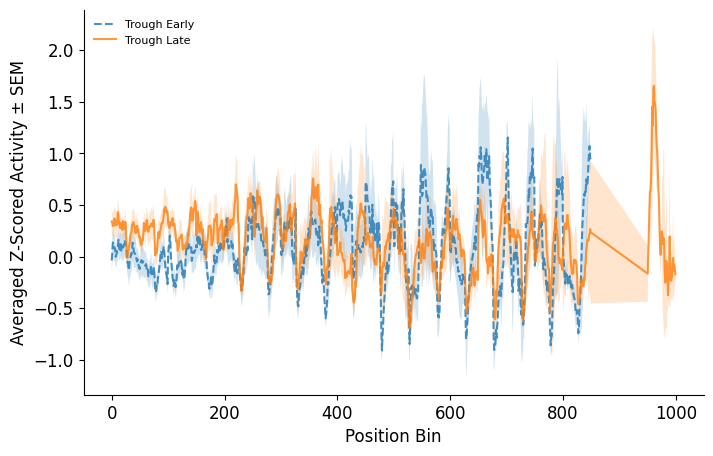

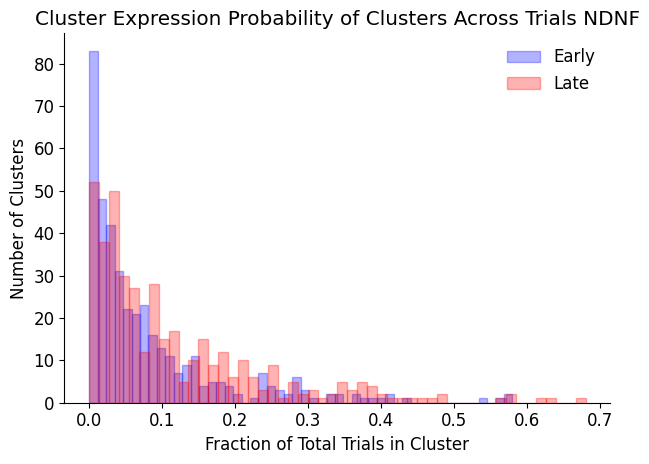

In [102]:


def plot_cluster_expression_probs_learning(clusters_dict_NDNF_early, clusters_dict_NDNF_late, residual_activity_dict_NDNF_newest, title=None, ylim=None, ax=None, alpha=None):
    proportion_trials_per_cluster_early = []
    for animal in clusters_dict_NDNF_early:
        for cell in clusters_dict_NDNF_early[animal]:
            total_num_trials = residual_activity_dict_NDNF_newest[animal][cell].shape[1]
            for i in range(len(clusters_dict_NDNF_early[animal][cell])):
                data = clusters_dict_NDNF_early[animal][cell][i]
                if np.mean(data) !=0:
                    num_trials = data.shape[0]
                    proportion_trials_per_cluster_early.append(num_trials/total_num_trials)

    
    # ax.hist(proportion_trials_per_cluster, bins=50, edgecolor='k')
    # ax.set_ylabel("Number of Clusters")
    # ax.set_title(f"Cluster Expression Probability of Clusters Across Trials {title}")
    # ax.set_xlabel("Fraction of Total Trials in Cluster")
    # ax.set_ylim(ylim)


    proportion_trials_per_cluster_late = []
    for animal in clusters_dict_NDNF_late:
        for cell in clusters_dict_NDNF_late[animal]:
            total_num_trials = residual_activity_dict_NDNF_newest[animal][cell].shape[1]
            for i in range(len(clusters_dict_NDNF_late[animal][cell])):
                data = clusters_dict_NDNF_late[animal][cell][i]
                if np.mean(data) !=0:
                    num_trials = data.shape[0]
                    proportion_trials_per_cluster_late.append(num_trials/total_num_trials)

    ax.hist(proportion_trials_per_cluster_early,alpha=alpha, color="blue", edgecolor="blue", bins=50, label='Early')
    ax.hist(proportion_trials_per_cluster_late, alpha=alpha, color='red', edgecolor="red", bins=50, label='Late')
    ax.set_ylabel("Number of Clusters")
    ax.set_title(f"Cluster Expression Probability of Clusters Across Trials {title}")
    ax.set_xlabel("Fraction of Total Trials in Cluster")
    ax.set_ylim(ylim)
    ax.legend()



    return proportion_trials_per_cluster_early, proportion_trials_per_cluster_late

fig, axs = plt.subplots()
proportion_trials_per_cluster_early, proportion_trials_per_cluster_late = plot_cluster_expression_probs_learning(clusters_dict_NDNF_early, clusters_dict_NDNF_late, residual_activity_dict_NDNF_newest, title="NDNF", ylim=None, ax=axs, alpha=0.3)
plt.tight_layout()
plt.show()


/Users/michaelfinch/CA1-interneuron-GLM/SliceTCA_example.py:480: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}


4
total_num_trials 66


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


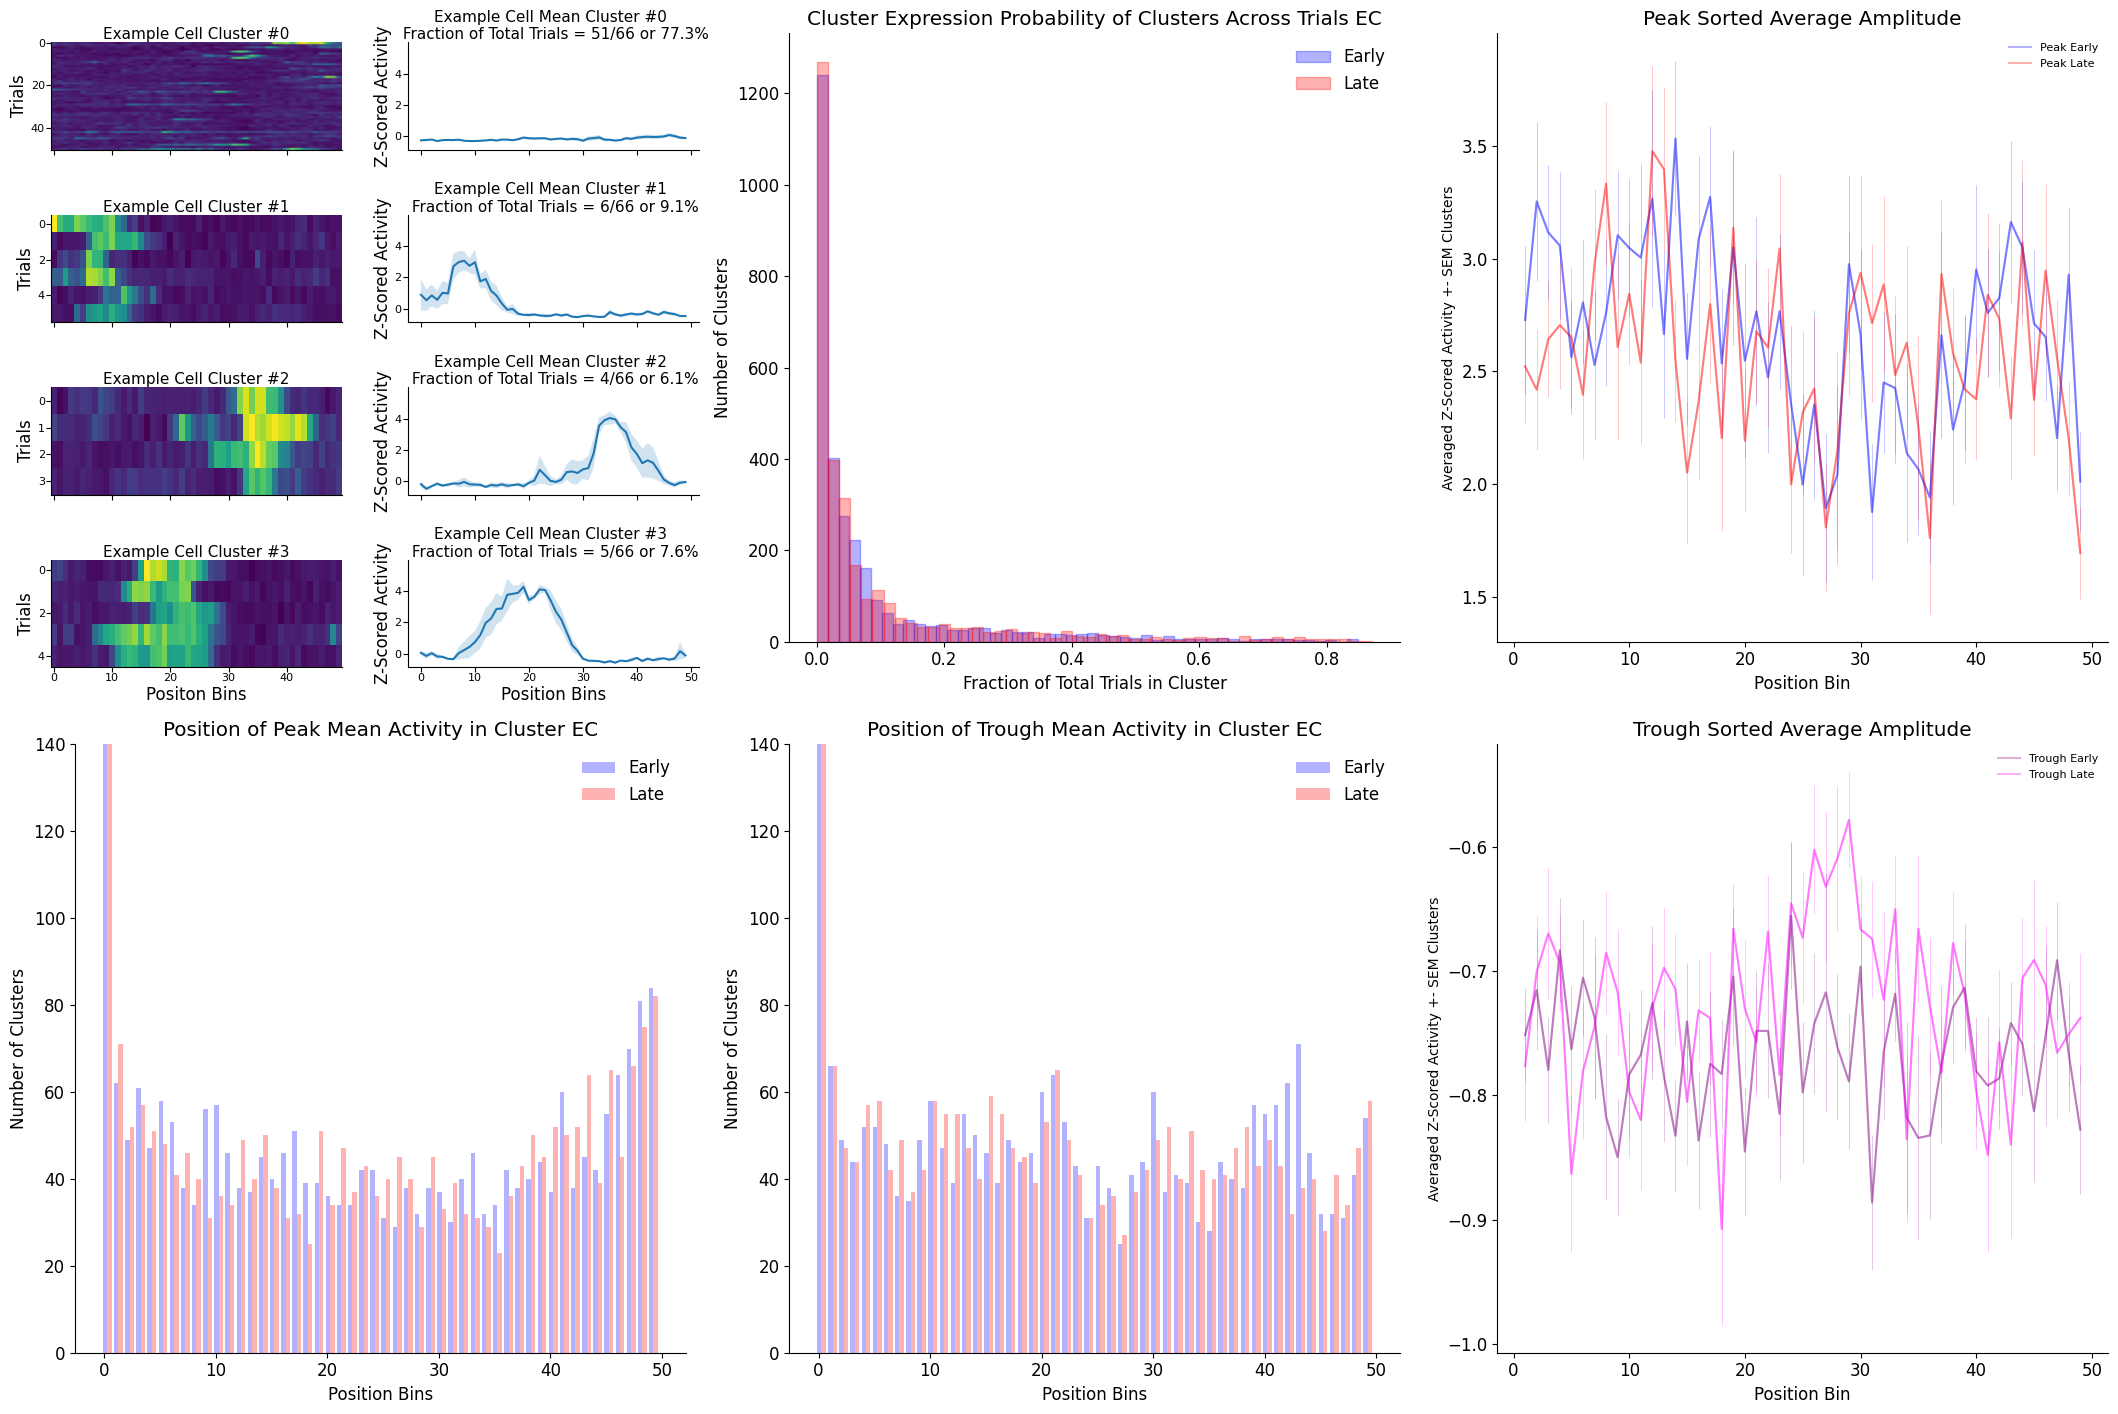

In [119]:


def plot_pop_stats_learning(clusters_dict_EC_early, clusters_dict_EC_late, clusters_dict_EC_overall, cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, animal=None, cell=None, cell_type="EC", ylim=None, alpha=None):

    fig = plt.figure(figsize=(21, 14), constrained_layout=True)

    indices_dict_EC_early = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, split_learn=True, eln="early")
    activity_indices_EC_dict_early = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_early)

    indices_dict_EC_late = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, split_learn=True, eln="late")
    activity_indices_EC_dict_late = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_late)

    indices_dict_EC = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, split_learn=False, eln="nothing")
    activity_indices_EC_dict = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC)

    max=0
    min=0
    activity_list = []
    for i in activity_indices_EC_dict[animal][cell]:
        activity = activity_indices_EC_dict[animal][cell][i]['activity']
        activity_list.append(activity)
        if np.max(activity) > max:
            max=np.max(activity)
        if np.min(activity) < min:
            min=np.min(activity)
        
    print(len(activity_list))

    # --- outer grid: make left column wide, shrink vertical gap between rows ---
    gs = plt.GridSpec(
        2, 3, figure=fig,
        width_ratios=[1.6, 1.6, 1.6],
        height_ratios=[1.0, 1.0]
    )

    # reduce global paddings/gaps for constrained_layout
    # (works in recent Matplotlib; fall back to set_constrained_layout_pads if needed)
    fig.get_layout_engine().set(h_pad=0.03, w_pad=0.01, hspace=0.04, wspace=0.04)

    # --- nested grid in top-left ---
    subgs = gs[0, 0].subgridspec(4, 2, hspace=0.08, wspace=0.03)

    # make nested axes
    ax00 = fig.add_subplot(subgs[0, 0]); ax01 = fig.add_subplot(subgs[0, 1])
    ax10 = fig.add_subplot(subgs[1, 0]); ax11 = fig.add_subplot(subgs[1, 1])
    ax20 = fig.add_subplot(subgs[2, 0]); ax21 = fig.add_subplot(subgs[2, 1])
    ax30 = fig.add_subplot(subgs[3, 0]); ax31 = fig.add_subplot(subgs[3, 1])

    # your plotting...

    total_num_trials = np.sum([activity_list[0].shape[1] + activity_list[1].shape[1] + activity_list[2].shape[1] + activity_list[3].shape[1]])
    print(f"total_num_trials {total_num_trials}")

    get_activity_array(activity_list[0], ax=ax00, i=0, total_num_trials=total_num_trials); get_mean_activity_array(activity_list[0], ax=ax01, i=0, min=min, max=max, total_num_trials=total_num_trials)
    get_activity_array(activity_list[1], ax=ax10, i=1, total_num_trials=total_num_trials); get_mean_activity_array(activity_list[1], ax=ax11, i=1, min=min, max=max, total_num_trials=total_num_trials)
    get_activity_array(activity_list[2], ax=ax20, i=2, total_num_trials=total_num_trials); get_mean_activity_array(activity_list[2], ax=ax21, i=2, min=min, max=max, total_num_trials=total_num_trials)
    get_activity_array(activity_list[3], ax=ax30, i=3, total_num_trials=total_num_trials); get_mean_activity_array(activity_list[3], ax=ax31, i=3, min=min, max=max, total_num_trials=total_num_trials)

    # ---- tidy nested labels to save vertical space ----
    for ax in [ax00, ax10, ax20]:           # hide repeated x labels on upper rows
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)
    for ax in [ax01, ax11, ax21]:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)

    # shrink title/label padding inside the nested block
    for ax in [ax00, ax01, ax10, ax11, ax20, ax21, ax30, ax31]:
        ax.set_title(ax.get_title(), fontsize=11, pad=2)
        ax.xaxis.labelpad = 2
        ax.yaxis.labelpad = 2
        ax.tick_params(labelsize=8, pad=1)

    # --- rest of the outer axes ---
    ax_big_01 = fig.add_subplot(gs[0, 1])
    ax_big_02 = fig.add_subplot(gs[0, 2])
    ax_big_10 = fig.add_subplot(gs[1, 0])
    ax_big_11 = fig.add_subplot(gs[1, 1])
    ax_big_12 = fig.add_subplot(gs[1, 2])
    # subgs12 = gs[1, 2].subgridspec(2, 1, hspace=0.08)   # adjust hspace as you like
    # ax_big_12_top = fig.add_subplot(subgs12[0, 0])      # EARLY
    # ax_big_12_bot = fig.add_subplot(subgs12[1, 0])      # LATE

    # plot_optimal_num_clusters_histogram(clusters_dict_EC_overall, title=cell_type, ylim=None, ax=ax_big_01)
    early_express_probs, late_express_probs = plot_cluster_expression_probs_learning(clusters_dict_EC_early, clusters_dict_EC_late, residual_activity_dict_EC, title=cell_type, ylim=None, ax=ax_big_01, alpha=alpha)
    early_means_argmax, late_means_argmax = plot_peak_trough_bargraphs(clusters_dict_EC_early, clusters_dict_EC_late, use_argmax=True, title=cell_type, ylim=ylim, ax=ax_big_10, alpha=0.3)
    early_means_argmin, late_means_argmin = plot_peak_trough_bargraphs(clusters_dict_EC_early, clusters_dict_EC_late, use_argmax=False, title=cell_type, ylim=ylim, ax=ax_big_11, alpha=0.3)
    plot_means_sems_max_min_learning(activity_indices_EC_dict_early, activity_indices_EC_dict_late, ax=ax_big_02, plot_peak=True, alpha=alpha)
    plot_means_sems_max_min_learning(activity_indices_EC_dict_early, activity_indices_EC_dict_late, ax=ax_big_12, plot_peak=False, alpha=alpha)


    # slightly tighten title pads on the outer plots too
    for ax in [ax_big_01, ax_big_02, ax_big_10, ax_big_11, ax_big_12]:
        ax.set_title(ax.get_title(), pad=6)

    plt.show()

    return early_means_argmax, late_means_argmax, early_means_argmin, late_means_argmin, early_express_probs, late_express_probs


early_means_argmax_EC, late_means_argmax_EC, early_means_argmin_EC, late_means_argmin_EC, early_express_probs_EC, late_express_probs_EC = plot_pop_stats_learning(clusters_dict_EC_early, clusters_dict_EC_late, clusters_dict_EC_overall, cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, animal='animal_2', cell='cell_4', cell_type="EC", ylim=140, alpha=0.3)

4
total_num_trials 212


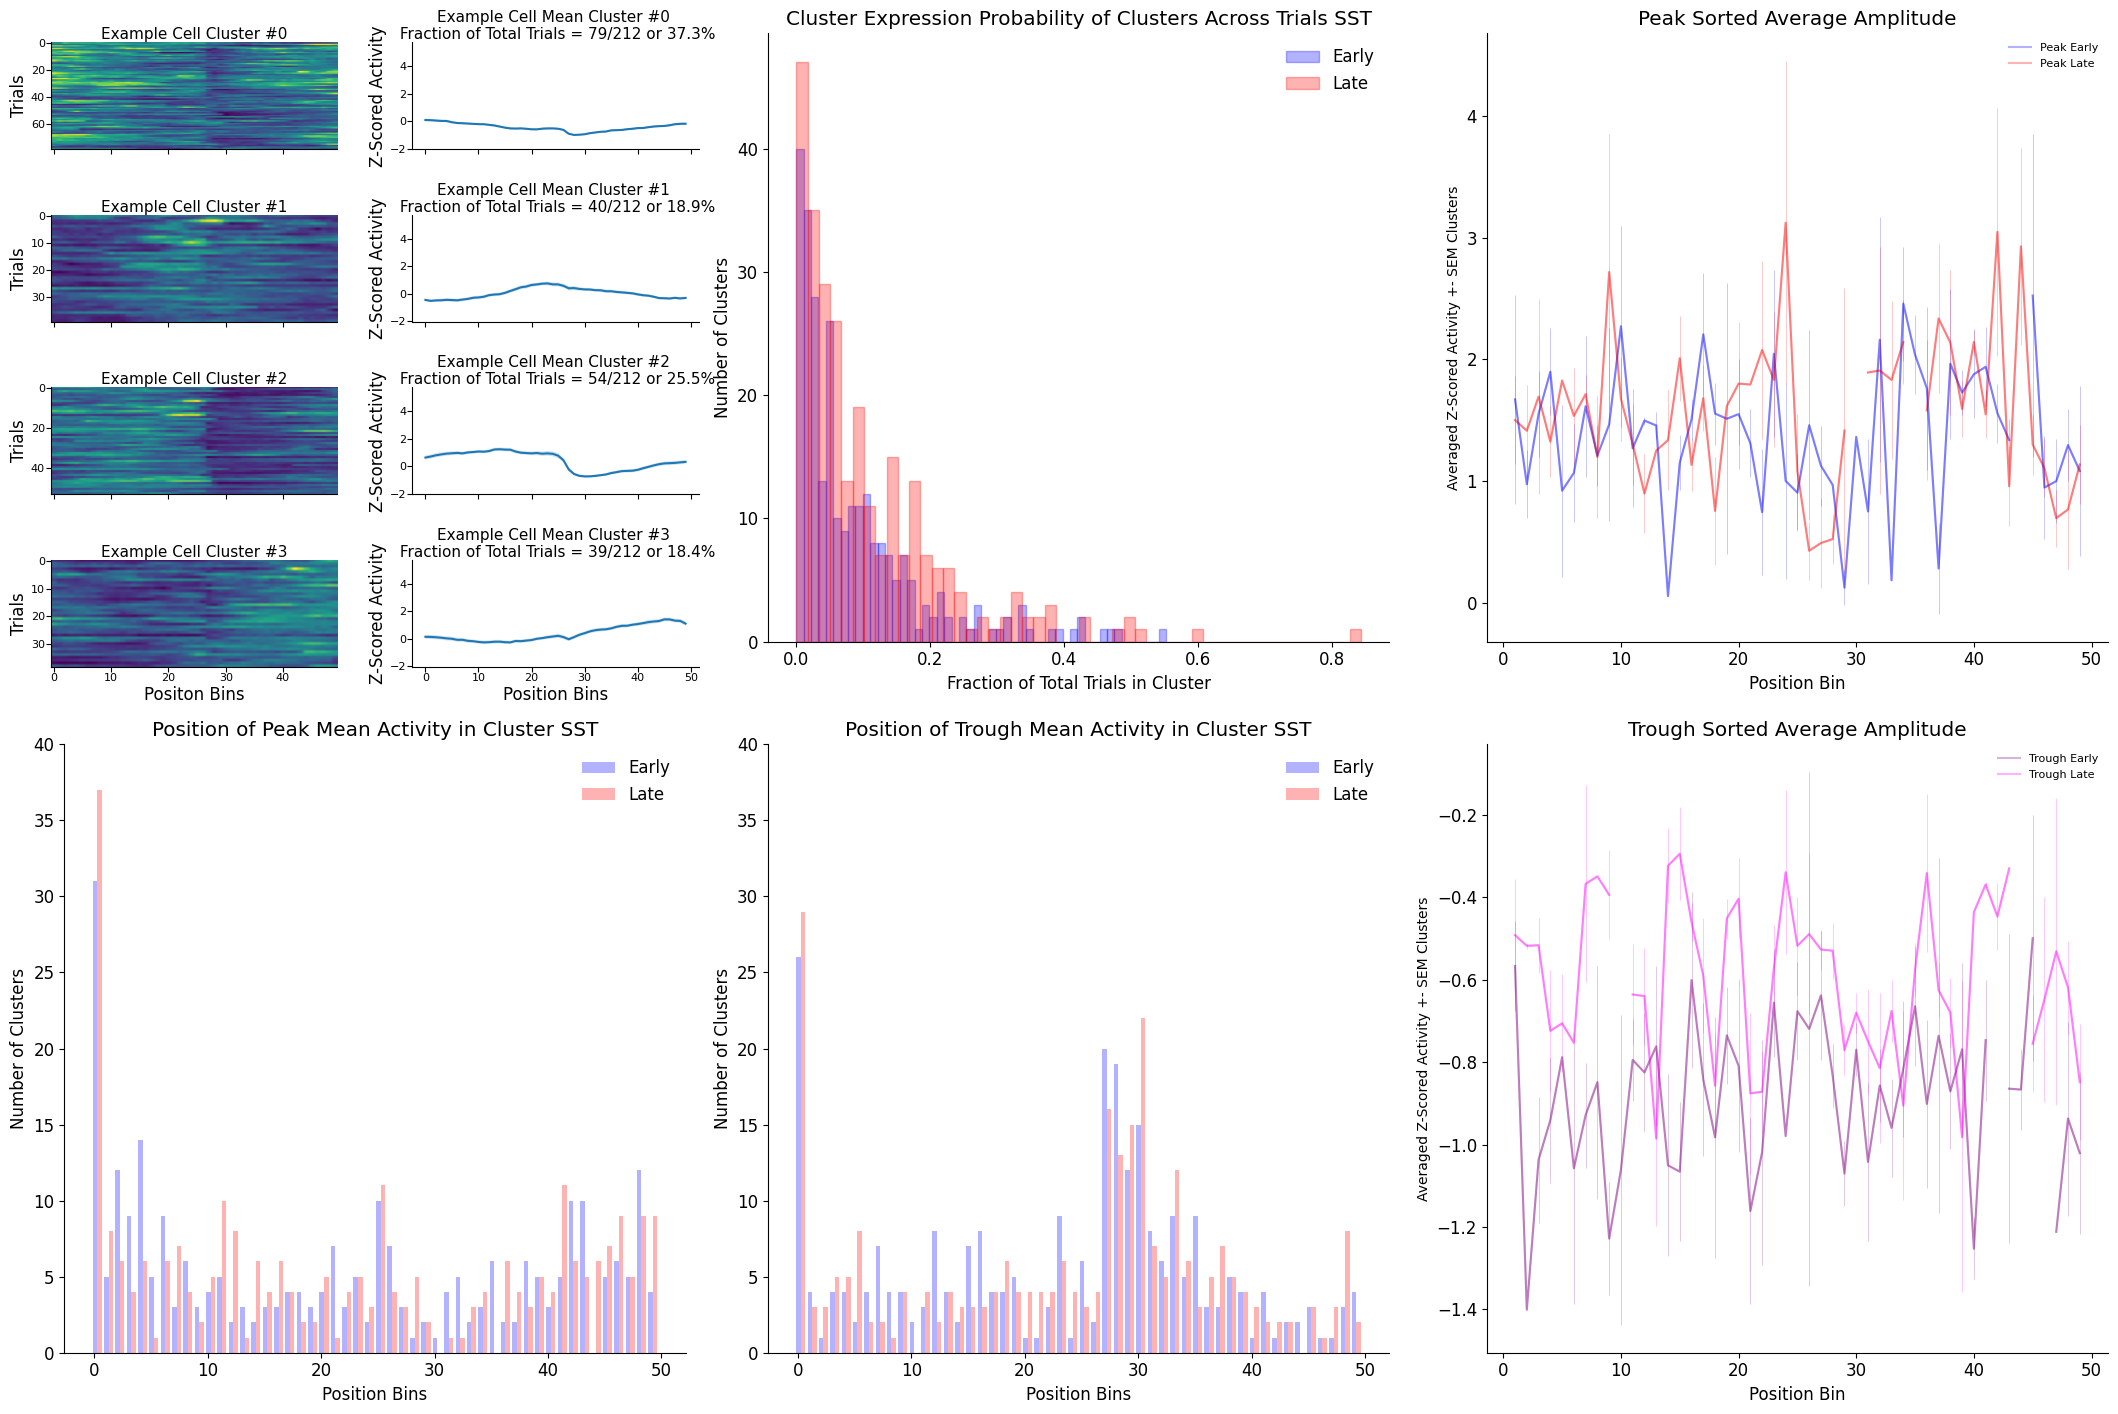

In [121]:
early_means_argmax_SST, late_means_argmax_SST, early_means_argmin_SST, late_means_argmin_SST, early_express_probs_SST, late_express_probs_SST  = plot_pop_stats_learning(clusters_dict_SST_early, clusters_dict_SST_late, clusters_dict_SST_overall, cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, animal='animal_1', cell='cell_2', cell_type="SST", ylim=40, alpha=0.3)

'/Users/michaelfinch/CA1-interneuron-GLM'

/Users/michaelfinch/CA1-interneuron-GLM/SliceTCA_example.py:480: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}


4
total_num_trials 107


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/michaelfinch/CA1-interneuron-GLM/SliceTCA_example.py:531: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  "sem": sem(peak_per_cluster_list)}


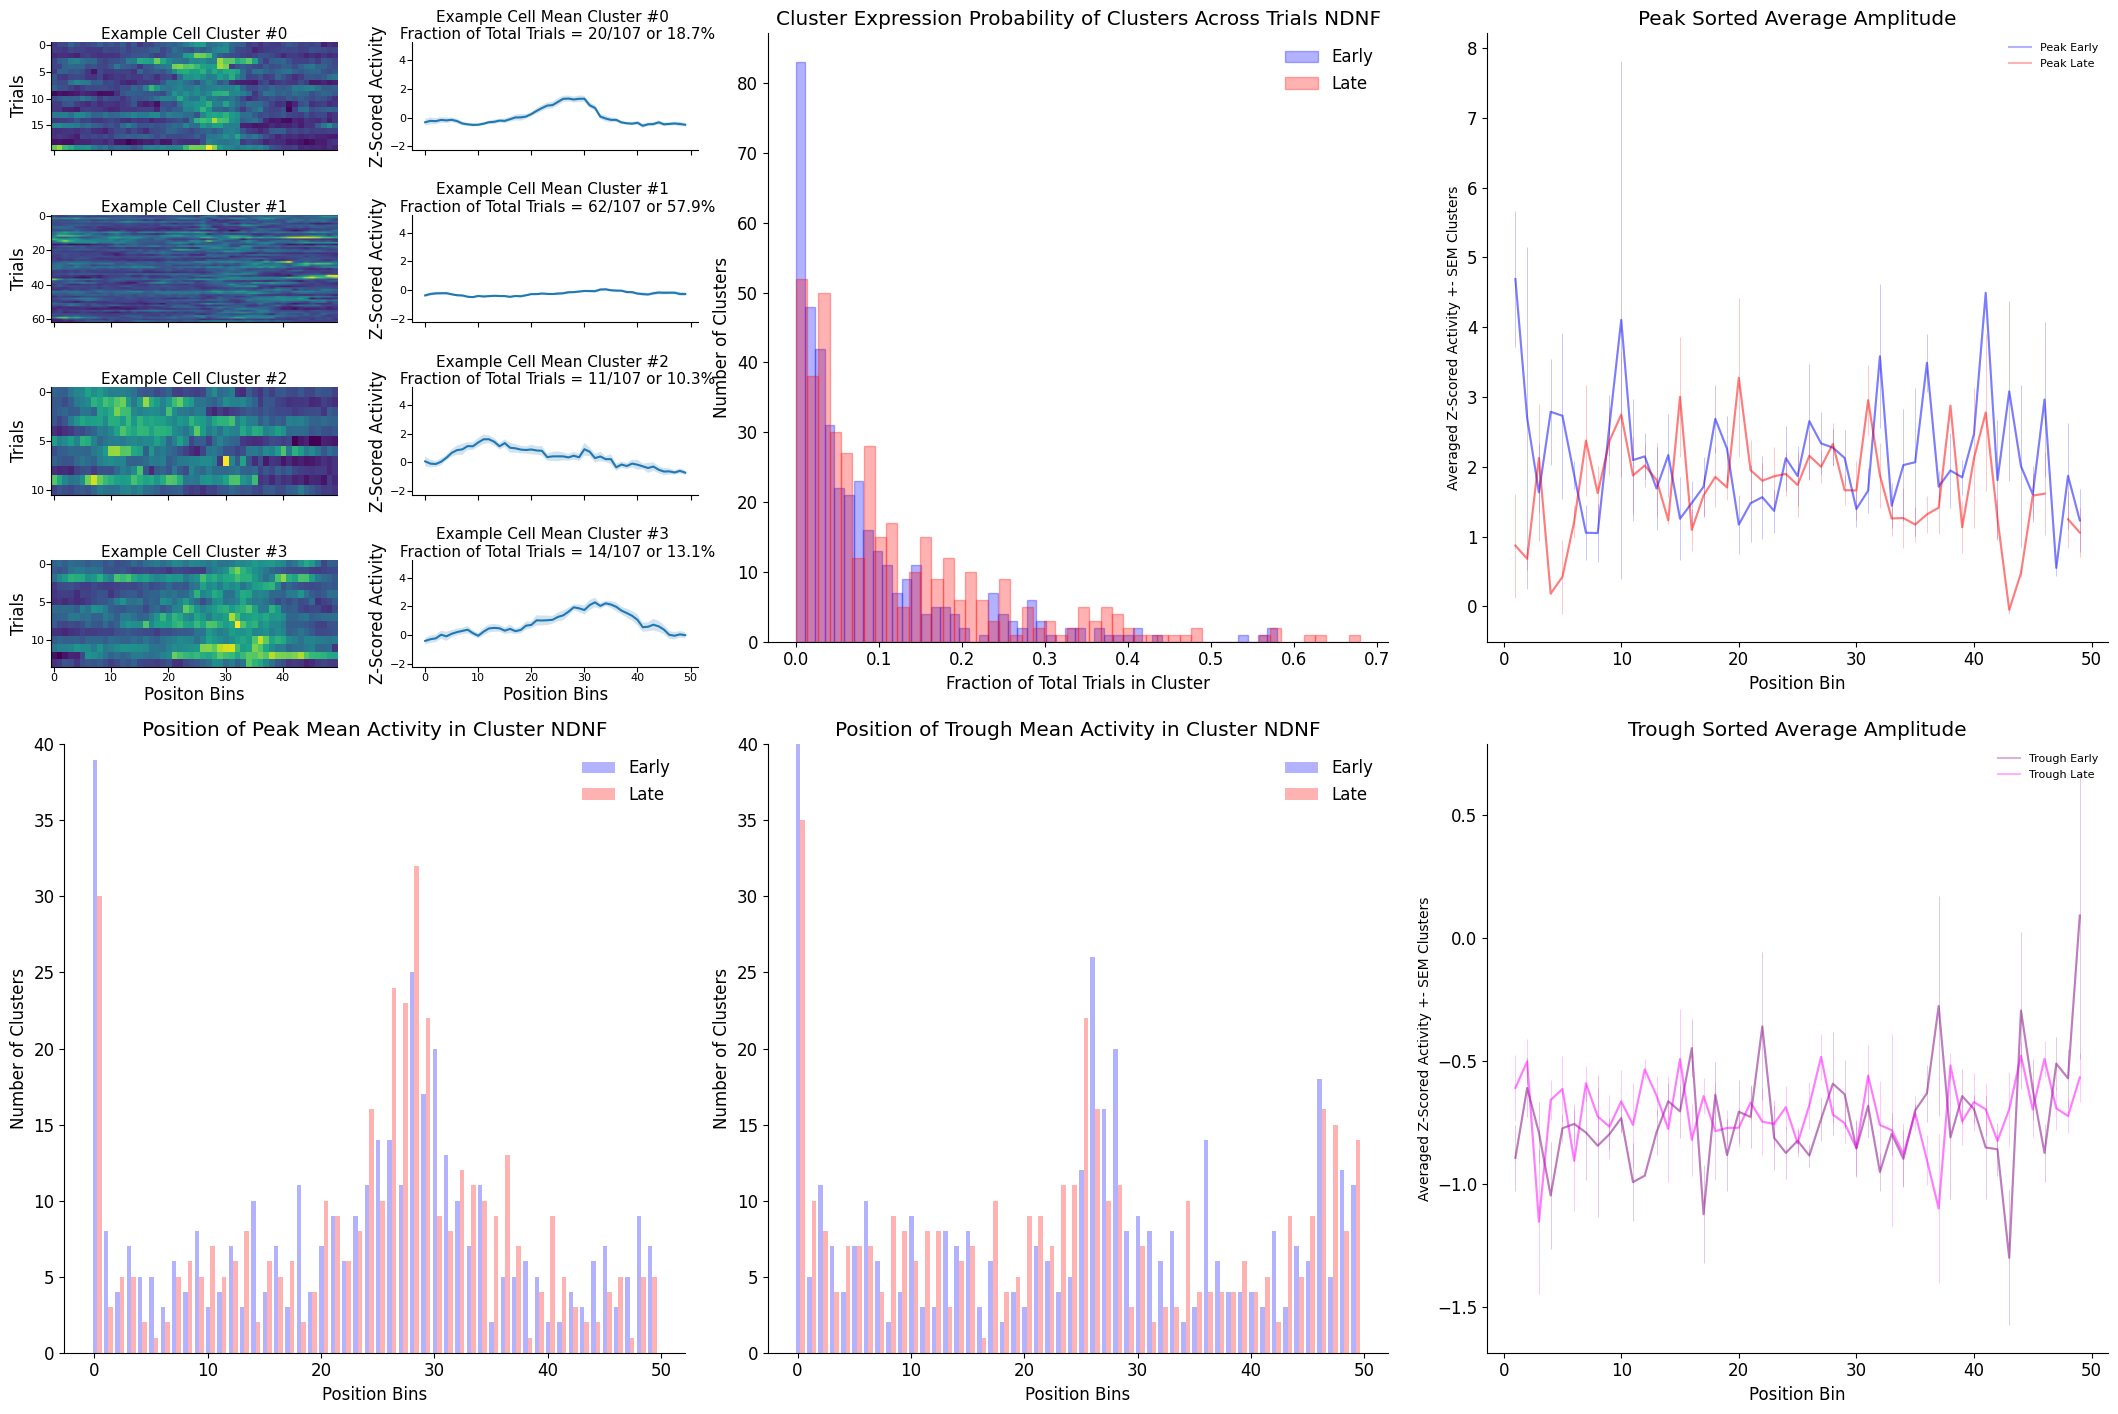

In [120]:
early_means_argmax_NDNF, late_means_argmax_NDNF, early_means_argmin_NDNF, late_means_argmin_NDNF, early_express_probs_NDNF, late_express_probs_NDNF  = plot_pop_stats_learning(clusters_dict_NDNF_early, clusters_dict_NDNF_late, clusters_dict_NDNF_overall, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, animal='animal_19', cell='cell_3', cell_type="NDNF", ylim=40, alpha=0.3)

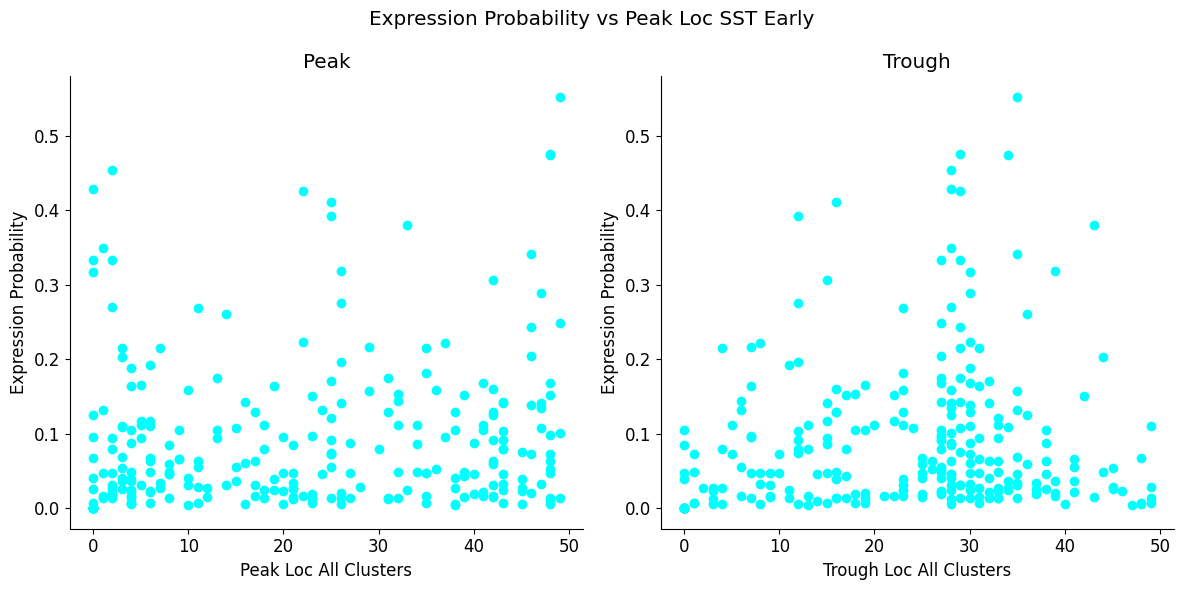

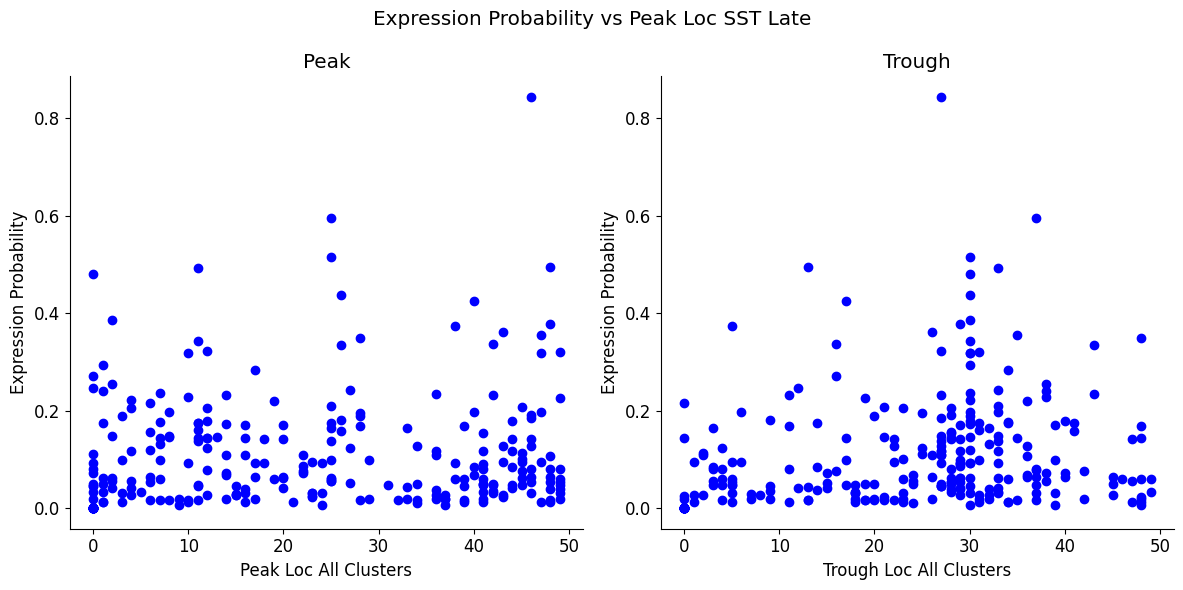

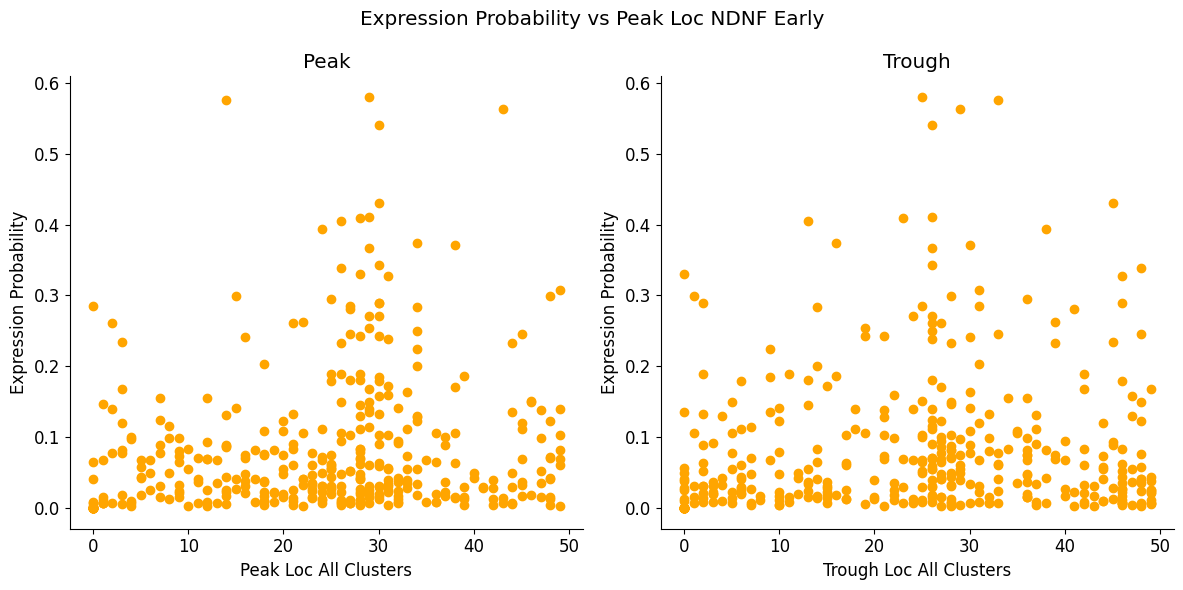

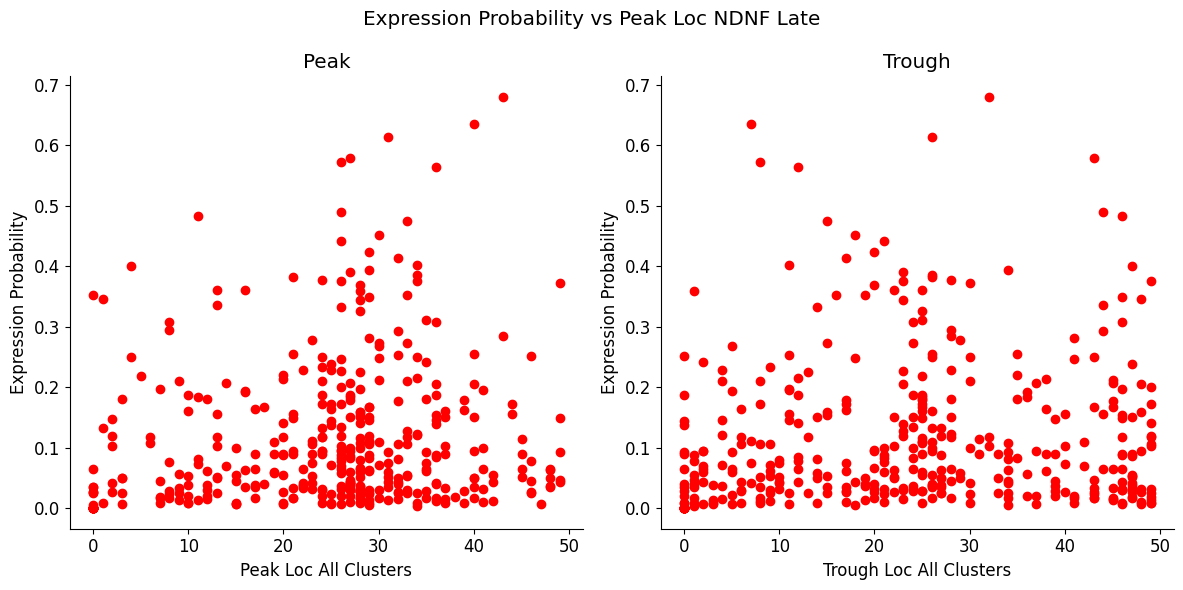

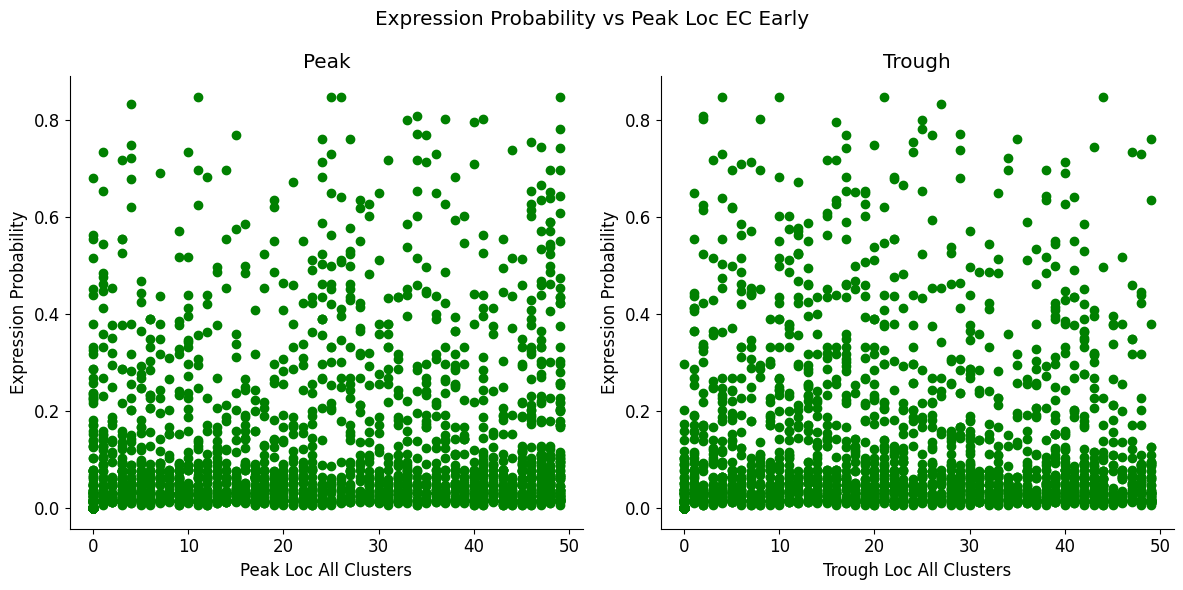

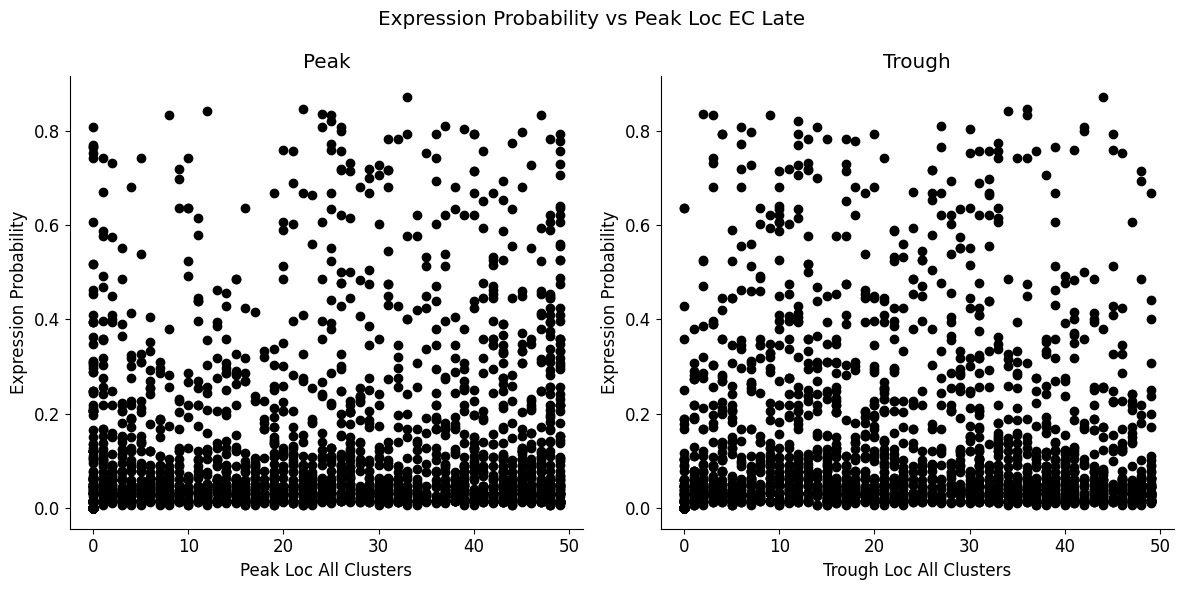

In [127]:
def plot_expression_prob_vs_freq(all_means_list_peak_SST, all_means_list_trough_SST, proportion_trials_per_cluster_SST, cell_type="SST", color=None):
    fig, axs = plt.subplots(1,2, figsize=(12,6))
    plt.suptitle(f"Expression Probability vs Peak Loc {cell_type}")
    axs[0].scatter(all_means_list_peak_SST,proportion_trials_per_cluster_SST, color=color)
    axs[0].set_ylabel("Expression Probability")
    axs[0].set_xlabel("Peak Loc All Clusters")
    axs[0].set_title("Peak")

    axs[1].scatter(all_means_list_trough_SST, proportion_trials_per_cluster_SST, color=color)
    axs[1].set_ylabel("Expression Probability")
    axs[1].set_xlabel("Trough Loc All Clusters")
    axs[1].set_title("Trough")
    plt.tight_layout()
    plt.show()

plot_expression_prob_vs_freq(early_means_argmax_SST, early_means_argmin_SST, early_express_probs_SST, cell_type="SST Early", color='cyan')
plot_expression_prob_vs_freq(late_means_argmax_SST, late_means_argmin_SST, late_express_probs_SST, cell_type="SST Late", color='blue')

plot_expression_prob_vs_freq(early_means_argmax_NDNF, early_means_argmin_NDNF, early_express_probs_NDNF, cell_type="NDNF Early", color='orange')
plot_expression_prob_vs_freq(late_means_argmax_NDNF, late_means_argmin_NDNF, late_express_probs_NDNF, cell_type="NDNF Late", color='red')

plot_expression_prob_vs_freq(early_means_argmax_EC, early_means_argmin_EC, early_express_probs_EC, cell_type="EC Early", color='green')
plot_expression_prob_vs_freq(late_means_argmax_EC, late_means_argmin_EC, late_express_probs_EC, cell_type="EC Late", color='k')

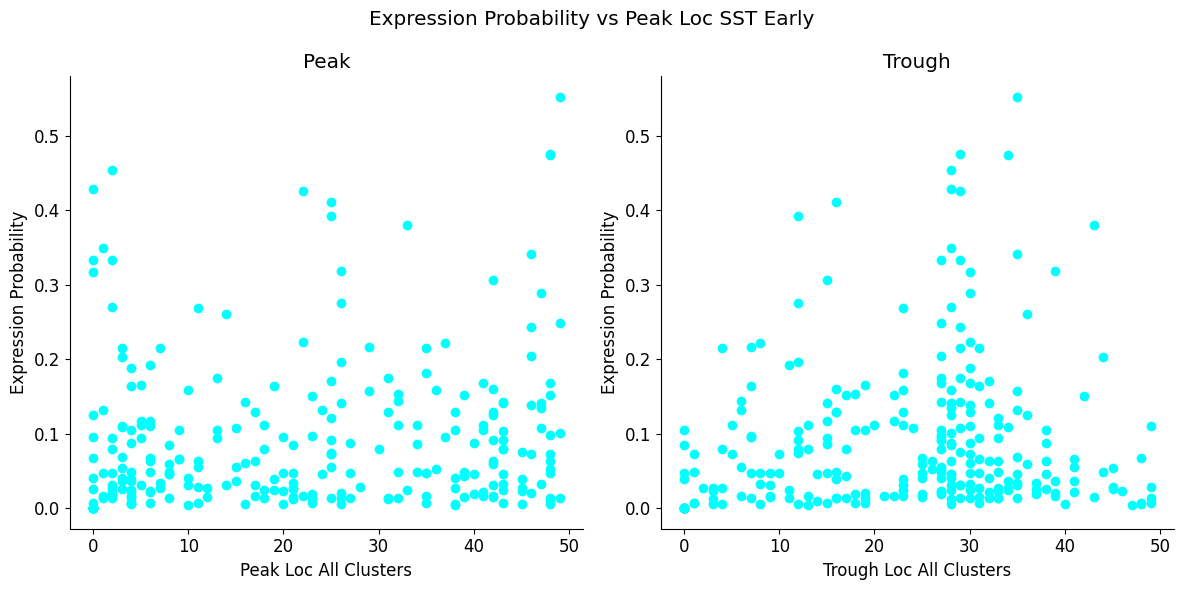

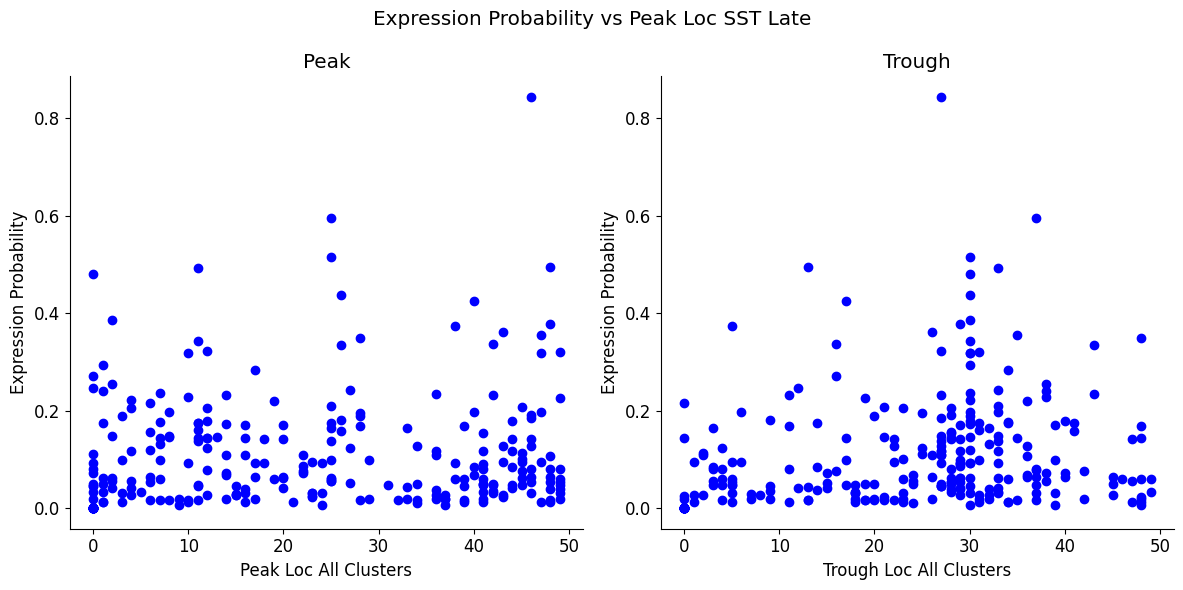

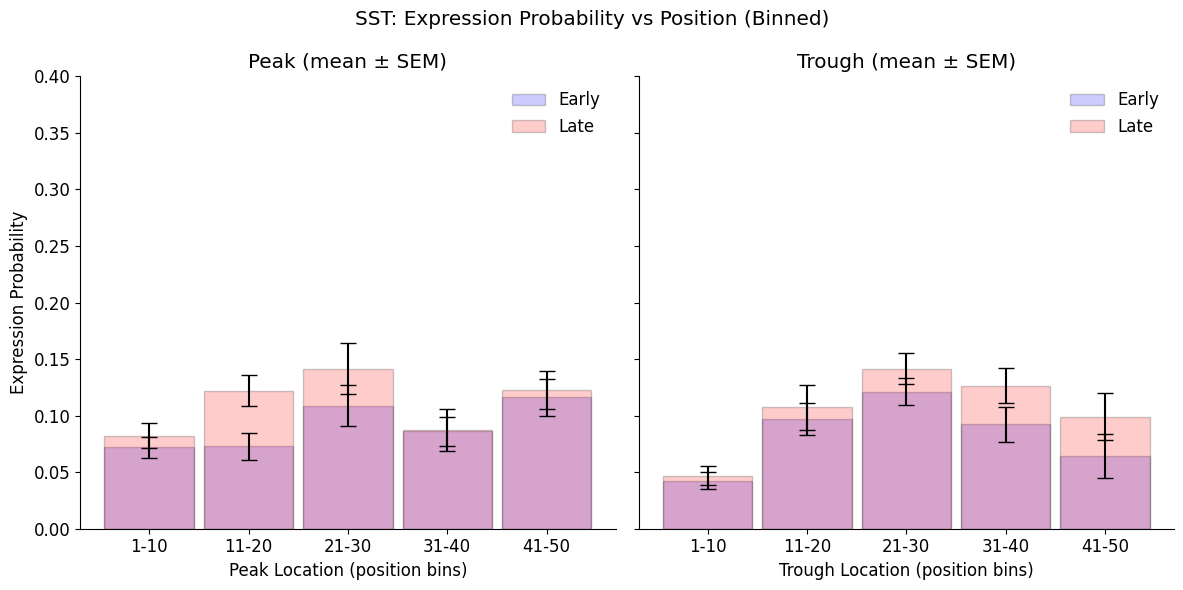

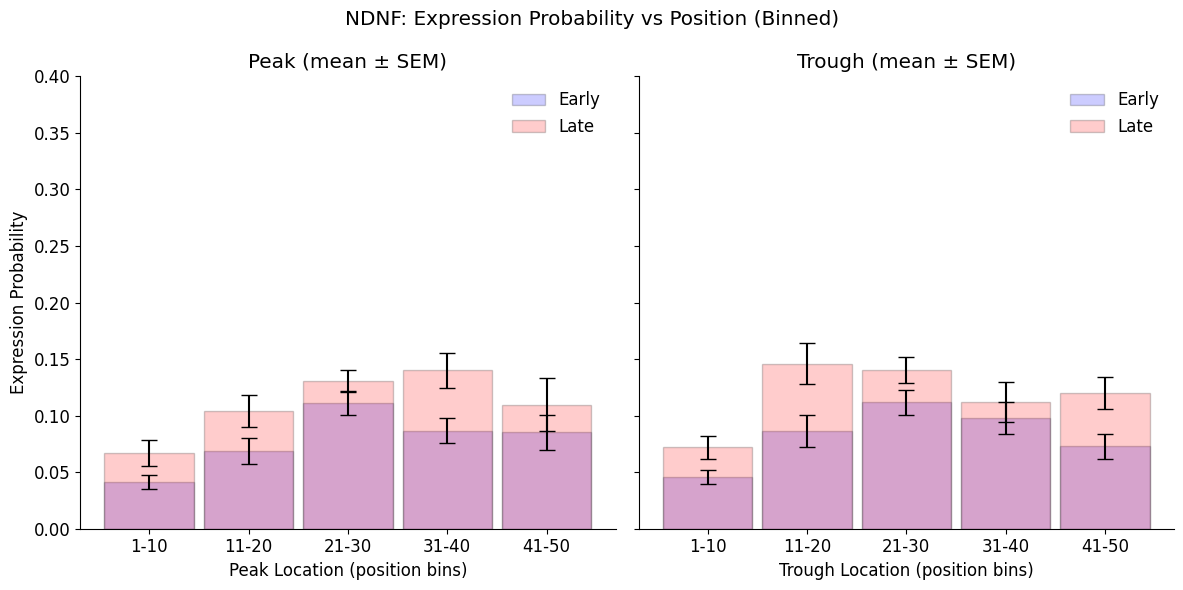

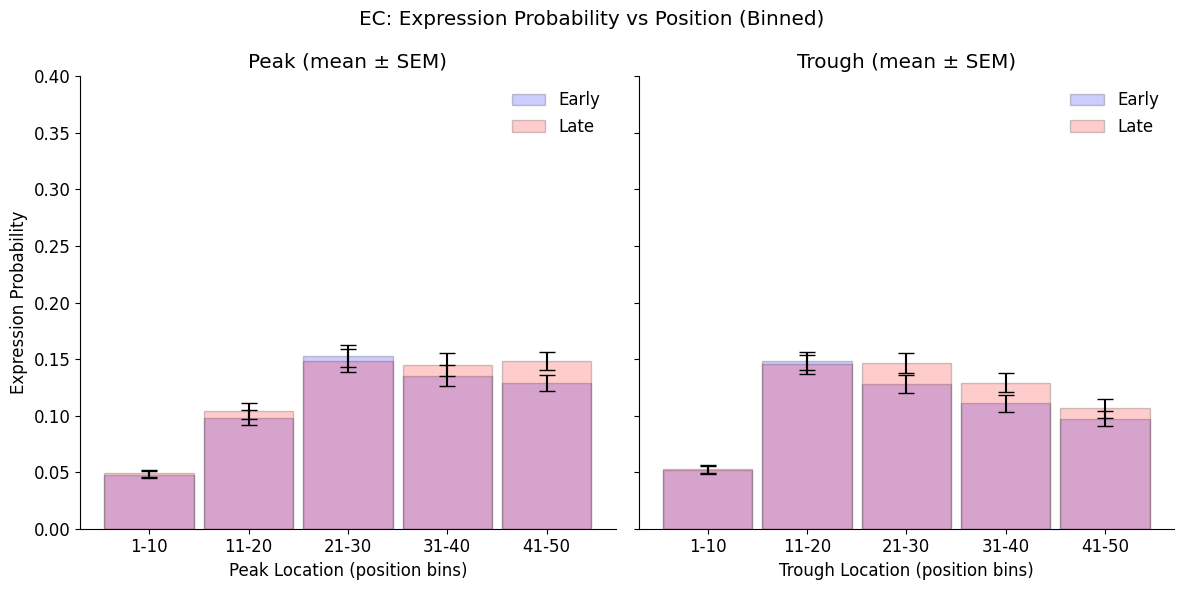

In [133]:
import numpy as np
from scipy.stats import sem
import matplotlib.pyplot as plt

def _bin_mean_sem(x, y, n_pos=50, bin_size=10, start_index=1):
    """
    Bin x into position bins (size=bin_size), compute mean±SEM of y in each bin.
    x: 1D array of peak/trough positions (e.g., 1..50)
    y: 1D array of expression probabilities (same length as x)
    start_index: 1 if positions are 1..n_pos, 0 if 0..n_pos-1
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    # Edges like [1,11,21,31,41,51] for 1-based indexing
    edges = np.arange(start_index, start_index + n_pos + bin_size, bin_size)
    n_bins = len(edges) - 1

    # Bin assignment: 0..n_bins-1
    b = np.digitize(x, edges, right=False) - 1
    b = np.clip(b, 0, n_bins - 1)

    means = np.full(n_bins, np.nan)
    sems  = np.full(n_bins, np.nan)
    labels = []
    for i in range(n_bins):
        in_bin = (b == i)
        if np.any(in_bin):
            vals = y[in_bin]
            means[i] = np.nanmean(vals)
            sems[i]  = sem(vals, nan_policy='omit')
        # labels like "1-10", "11-20", etc. for 1-based; "0-9" if start_index=0
        lo = int(edges[i])
        hi = int(edges[i+1] - (1 if start_index == 1 else 0))
        labels.append(f"{lo}-{hi}")
    return means, sems, labels
plot_expression_prob_vs_freq(early_means_argmax_SST, early_means_argmin_SST, early_express_probs_SST, cell_type="SST Early", color='cyan')
plot_expression_prob_vs_freq(late_means_argmax_SST, late_means_argmin_SST, late_express_probs_SST, cell_type="SST Late", color='blue')
def plot_expression_prob_vs_freq_binned(all_means_list_peak_SST_early,
                                        all_means_list_trough_SST_early,
                                        proportion_trials_per_cluster_SST_early,
                                        all_means_list_peak_SST_late,
                                        all_means_list_trough_SST_late,
                                        proportion_trials_per_cluster_SST_late,
                                        cell_type="SST",
                                        n_pos=50, bin_size=10, start_index=1, ylim=None):
    """
    Bins peak/trough locations into groups of 'bin_size' position bins,
    then plots mean ± SEM of expression probability per bin.
    """
    peak_means_early, peak_sems_early, peak_labels_early = _bin_mean_sem(all_means_list_peak_SST_early, proportion_trials_per_cluster_SST_early, n_pos=n_pos, bin_size=bin_size, start_index=start_index)
    peak_means_late, peak_sems_late, peak_labels_late = _bin_mean_sem(all_means_list_peak_SST_late, proportion_trials_per_cluster_SST_late, n_pos=n_pos, bin_size=bin_size, start_index=start_index)

    
    trough_means_early, trough_sems_early, trough_labels_early = _bin_mean_sem(all_means_list_trough_SST_early, proportion_trials_per_cluster_SST_early, n_pos=n_pos, bin_size=bin_size, start_index=start_index)
    trough_means_late, trough_sems_late, trough_labels_late = _bin_mean_sem(all_means_list_trough_SST_late, proportion_trials_per_cluster_SST_late, n_pos=n_pos, bin_size=bin_size, start_index=start_index)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    plt.suptitle(f"{cell_type}: Expression Probability vs Position (Binned)")

    x0 = np.arange(len(peak_means_early))
    axs[0].bar(x0, peak_means_early, yerr=peak_sems_early, capsize=6, edgecolor='k', width=0.9, label='Early', color='b', alpha=0.2)
    axs[0].set_xticks(x0, peak_labels_early, rotation=0)
    axs[0].bar(x0, peak_means_late, yerr=peak_sems_late, capsize=6, edgecolor='k', width=0.9, label='Late', color='r', alpha=0.2)
    axs[0].set_xticks(x0, peak_labels_late, rotation=0)
    axs[0].set_xlabel("Peak Location (position bins)")
    axs[0].set_ylabel("Expression Probability")
    axs[0].set_ylim(0,ylim)
    axs[0].set_title("Peak (mean ± SEM)")
    axs[0].legend()

    x1 = np.arange(len(trough_means_early))
    axs[1].bar(x1, trough_means_early, yerr=trough_sems_early, capsize=6, edgecolor='k', width=0.9, label='Early', color='b', alpha=0.2)
    axs[1].set_xticks(x0, trough_labels_early, rotation=0)
    axs[1].bar(x1, trough_means_late, yerr=trough_sems_late, capsize=6, edgecolor='k', width=0.9, label='Late', color='r', alpha=0.2)
    axs[1].set_xticks(x0, trough_labels_late, rotation=0)
    axs[1].set_xlabel("Trough Location (position bins)")
    axs[1].set_title("Trough (mean ± SEM)")
    axs[1].set_ylim(0,ylim)
    axs[1].legend()

    plt.tight_layout()
    plt.show()


plot_expression_prob_vs_freq_binned(early_means_argmax_SST, early_means_argmin_SST, early_express_probs_SST, late_means_argmax_SST, late_means_argmin_SST, late_express_probs_SST,
    cell_type="SST",
    n_pos=50,
    bin_size=10,     # makes 5 bars: 1–10, 11–20, ...
    start_index=1,    # set to 0 if your positions are 0..49
    ylim=0.4
)


plot_expression_prob_vs_freq_binned(early_means_argmax_NDNF, early_means_argmin_NDNF, early_express_probs_NDNF, late_means_argmax_NDNF, late_means_argmin_NDNF, late_express_probs_NDNF,
    cell_type="NDNF",
    n_pos=50,
    bin_size=10,     # makes 5 bars: 1–10, 11–20, ...
    start_index=1,   # set to 0 if your positions are 0..49
    ylim=0.4,
)


plot_expression_prob_vs_freq_binned(early_means_argmax_EC, early_means_argmin_EC, early_express_probs_EC, late_means_argmax_EC, late_means_argmin_EC, late_express_probs_EC,
    cell_type="EC",
    n_pos=50,
    bin_size=10,     # makes 5 bars: 1–10, 11–20, ...
    start_index=1,    # set to 0 if your positions are 0..49
    ylim=0.4,
)

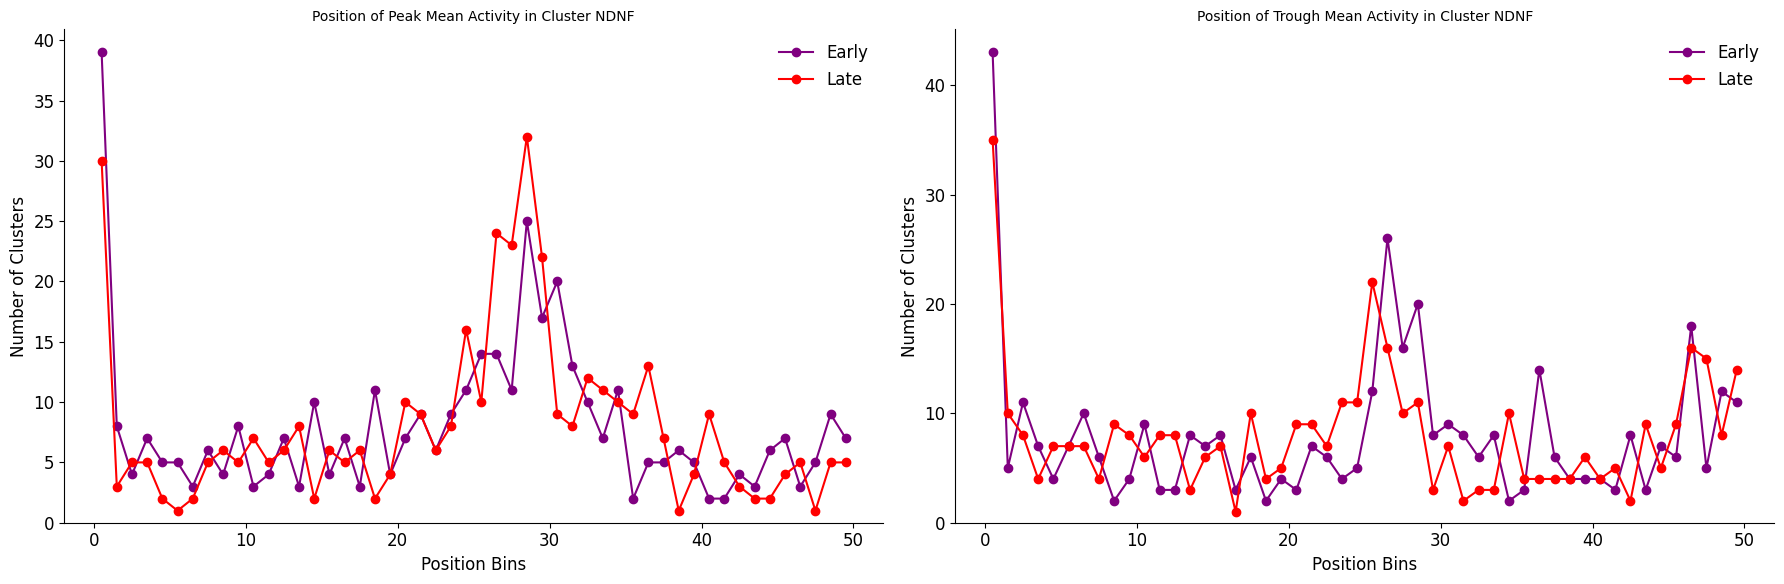

In [10]:
def plot_peak_trough_lines(clusters_dict_NDNF_early, clusters_dict_NDNF_late, use_argmax=True, title=None, ylim=None, ax=None, alpha=0.8):
    import numpy as np

    early_means = []
    late_means = []

    # Collect early data
    for animal in clusters_dict_NDNF_early:
        for cell in clusters_dict_NDNF_early[animal]:
            for i in range(len(clusters_dict_NDNF_early[animal][cell])):
                data = clusters_dict_NDNF_early[animal][cell][i]
                mean_data = np.mean(data, axis=0)
                early_means.append(np.argmax(mean_data) if use_argmax else np.argmin(mean_data))

    # Collect late data
    for animal in clusters_dict_NDNF_late:
        for cell in clusters_dict_NDNF_late[animal]:
            for i in range(len(clusters_dict_NDNF_late[animal][cell])):
                data = clusters_dict_NDNF_late[animal][cell][i]
                mean_data = np.mean(data, axis=0)
                late_means.append(np.argmax(mean_data) if use_argmax else np.argmin(mean_data))

    # Bin counts
    bins = np.arange(0, 51)  # 50 bins
    early_counts, _ = np.histogram(early_means, bins=bins)
    late_counts, _ = np.histogram(late_means, bins=bins)

    bin_centers = bins[:-1] + 0.5

    # Plot as lines with "o" markers
    ax.plot(bin_centers, early_counts, marker='o', color='purple', alpha=alpha, label='Early')
    ax.plot(bin_centers, late_counts, marker='o', color='red', alpha=alpha, label='Late')

    ax.set_title(f"Position of {'Peak' if use_argmax else 'Trough'} Mean Activity in Cluster {title}", fontsize=10)
    ax.set_ylabel("Number of Clusters")
    ax.set_xlabel("Position Bins")
    ax.set_ylim(0, ylim)
    ax.legend()

    return early_means, late_means

fig, axs = plt.subplots(1,2, figsize=(18,6))
early_means, late_means = plot_peak_trough_lines(clusters_dict_NDNF_early, clusters_dict_NDNF_late, use_argmax=True, title="NDNF", ylim=None, ax=axs[0], alpha=1)
early_means, late_means = plot_peak_trough_lines(clusters_dict_NDNF_early, clusters_dict_NDNF_late, use_argmax=False, title="NDNF", ylim=None, ax=axs[1], alpha=1)
plt.tight_layout()
plt.show()


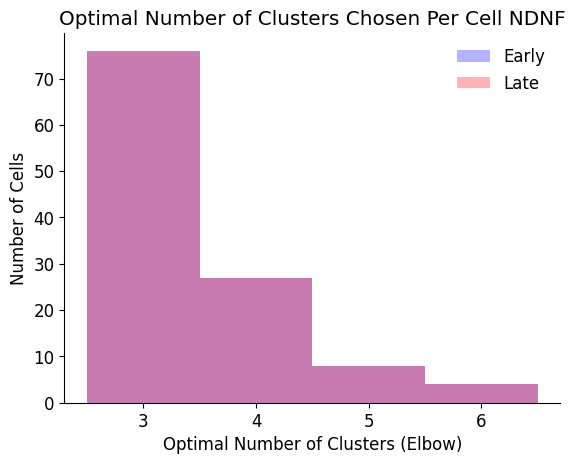

In [ ]:
def plot_optimal_num_clusters_histogram_learning(clusters_dict_NDNF_early, clusters_dict_NDNF_late, title=None, ylim=None, ax=None, alpha=None):
    
    all_means_num_clusters_early = []

    for animal in clusters_dict_NDNF_early:
        for cell in clusters_dict_NDNF_early[animal]:
            valid_length=0
            for i in range(len(clusters_dict_NDNF_early[animal][cell])):
                # if np.mean(clusters_dict_NDNF_early[animal][cell][i] !=0):
                valid_length+=1
            all_means_num_clusters_early.append(valid_length)

    data_labels=np.unique(all_means_num_clusters_early)

    all_means_num_clusters_late = []

    for animal in clusters_dict_NDNF_late:
        for cell in clusters_dict_NDNF_late[animal]:
            valid_length=0
            for i in range(len(clusters_dict_NDNF_late[animal][cell])):
                # if np.mean(clusters_dict_NDNF_early[animal][cell][i] !=0):
                valid_length+=1
            all_means_num_clusters_late.append(valid_length)

    data_labels=np.unique(all_means_num_clusters_late)
    
    counts, bins, patches = ax.hist(all_means_num_clusters_early, bins=4, edgecolor='k' color='b', alpha=alpha, label='Early')
    counts, bins, patches = ax.hist(all_means_num_clusters_late, bins=4, color='r', alpha=alpha, label='Late')
    ax.set_xlabel("Optimal Number of Clusters (Elbow)")
    ax.set_title(f"Optimal Number of Clusters Chosen Per Cell {title}")
    ax.set_ylabel("Number of Cells")
    ax.legend()
    # Place xticks in the middle of each bar
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ax.set_xticks(bin_centers, data_labels)
    ax.set_ylim(ylim)

fig, axs=plt.subplots()
plot_optimal_num_clusters_histogram_learning(clusters_dict_NDNF_early, clusters_dict_NDNF_late, title="NDNF", ylim=None, ax=axs, alpha=0.3)
plt.show()
